<a href="https://colab.research.google.com/github/ByungChul-Cha/Deep_Learning_Study/blob/main/Day04/%EC%86%8C%ED%94%84%ED%8A%B8%EB%A7%A5%EC%8A%A4_%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **05-01. One-hot Encoding(원-핫 인코딩)**

# 원-핫 인코딩이란?
- 선택해야 하는 선택지의 개수만큼의 차원을 가지면서,
- 각 선택지의 인덱스에 해당하는 원소에는 1, 나머지 원소는 0의 값을 가지도록 하는 표현 방법
- 원-핫 벡터: 원-핫 인코딩으로 표현된 벡터

# 원-핫 벡터의 무작위성
- 각 클래스 간의 관계가 균등하다는 점에서 적절한 표현 방법
- 정수 인코딩 방식도 사용 가능
  - 클래스 간 순서의 의미를 가지고 있을 때
- 정수 인코딩 보다 클래스의 성질을 잘 표현
  - 분류 문제 모든 클래스 간의 관계를 균등하게 분배

-> 원-핫 벡터들은 모든 쌍에 대해서 유클리드 거리를 구해도 전부 동일

# **05-02. Softmax Regression(소프트맥스 회귀)**

# Multi-class Classification(다중 클래스 분류)
- 세 개 이상의 답 중 하나를 고르는 문제

# Softmax function(소프트맥스 함수)
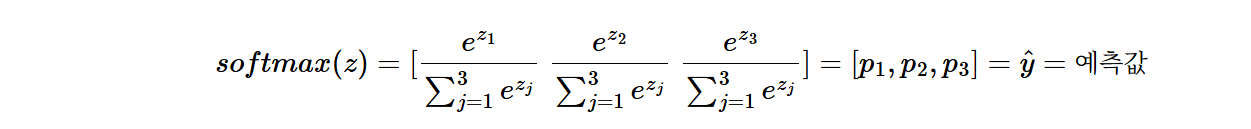

# Cost function(비용 함수)
- 크로스 엔트로피 함수 사용
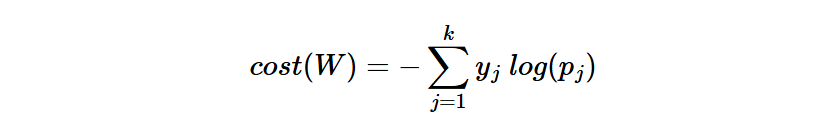
- 최종 비용 함수
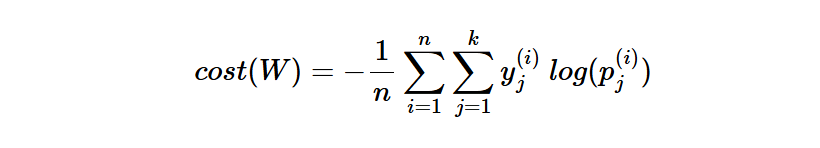

# **05-03. 소프트맥스 회귀 다양한 방법으로 구현하기**

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1)

- 로우-레벨로 구현

In [8]:
z = torch.FloatTensor([1,2,3,])

In [9]:
hypothesis = F.softmax(z, dim=0)
print(hypothesis)

tensor([0.0900, 0.2447, 0.6652])


In [10]:
hypothesis.sum()

tensor(1.)

In [11]:
z = torch.rand(3, 5, requires_grad=True)

In [12]:
hypothesis = F.softmax(z, dim=1)
print(hypothesis)

tensor([[0.1495, 0.1879, 0.1643, 0.3013, 0.1969],
        [0.2556, 0.1132, 0.2942, 0.2193, 0.1177],
        [0.1082, 0.2797, 0.1725, 0.1937, 0.2460]], grad_fn=<SoftmaxBackward0>)


In [13]:
y = torch.randint(5, (3,)).long()
print(y)

tensor([3, 0, 1])


In [15]:
y_one_hot = torch.zeros_like(hypothesis)
y_one_hot.scatter_(1, y.unsqueeze(1), 1)

tensor([[0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.]])

In [17]:
print(y.unsqueeze(1))

tensor([[3],
        [0],
        [1]])


In [18]:
cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()
print(cost)

tensor(1.2793, grad_fn=<MeanBackward0>)


- 하이-레벨로 구현하기

In [22]:
# Low level
torch.log(F.softmax(z, dim=1))

# High level
F.log_softmax(z, dim=1)

tensor([[-1.9005, -1.6716, -1.8060, -1.1996, -1.6248],
        [-1.3640, -2.1784, -1.2236, -1.5173, -2.1398],
        [-2.2241, -1.2742, -1.7575, -1.6416, -1.4023]],
       grad_fn=<LogSoftmaxBackward0>)

tensor([[-1.9005, -1.6716, -1.8060, -1.1996, -1.6248],
        [-1.3640, -2.1784, -1.2236, -1.5173, -2.1398],
        [-2.2241, -1.2742, -1.7575, -1.6416, -1.4023]], grad_fn=<LogBackward0>)

In [31]:
# Low level
(y_one_hot * -torch.log(F.softmax(z, dim=1))).sum(dim=1).mean()

# Middle(?) level
(y_one_hot * - F.log_softmax(z, dim=1)).sum(dim=1).mean()

# High level
# nll은 Negative Log Likelihood의 약자
F.nll_loss(F.log_softmax(z, dim=1), y)

# 네번째 수식
# F.log_softmax()와 F.nll_koss()를 포함
F.cross_entropy(z, y)

nn.CrossEntropyLoss()(z,y)

tensor(1.2793, grad_fn=<NllLossBackward0>)

- F.cross_entropy()
  - 함수임
  - 호출할 때마다 F.cross_entropy(입력, 정답) 형태로 사용
  - 매번 호출시 필요한 설정을 인자로 전달
- nn.CrossEntropyLoss()
  - 클래스임
  - 실제 사용할 수 있는 객체를 생성해야 함
  - 만들 때 설정값들을 미리 정해두고, 나중에 계속 재사용 가능

In [32]:
# 보통 다음과 같이 사용
# 1단계: 클래스로 객체 생성
criterion = nn.CrossEntropyLoss()

# 2단계: 생성된 객체 사용
loss = criterion(z, y)
print(loss)

tensor(1.2793, grad_fn=<NllLossBackward0>)


In [34]:
# 손실값의 평균 대신 합계가 필요한 경우
criterion_sum = nn.CrossEntropyLoss(reduction='sum')

# 같은 객체로 여러 번 계산 가능
sum_loss1 = criterion_sum(z, y)
sum_loss2 = criterion_sum(z, y)

# 새로운 데이터가 있다면
z2 = torch.rand(3, 5, requires_grad=True)
y2 = torch.randint(5, (3,)).long()
sum_loss3 = criterion_sum(z2, y2)

# 소프트맥스 회귀 구현

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

In [51]:
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

In [39]:
y_one_hot = torch.zeros(8, 3)
y_one_hot.scatter_(1, y_train.unsqueeze(1), 1)
print(y_one_hot.shape)

torch.Size([8, 3])


In [49]:
# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

In [46]:
# Low level
nb_epochs = 1000
for epoch in range(nb_epochs + 1):
  hypothesis  = F.softmax(x_train.matmul(W) + b, dim = 1)

  cost = (y_one_hot * - torch.log(hypothesis)).sum(dim = 1).mean()

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if (epoch%100 == 0):
    print('Epoch {:4d}/{} Cost: {:6f}'.format(
        epoch, nb_epochs, cost.item()
    ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.622999
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467661
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285072
Epoch 1000/1000 Cost: 0.248155


In [44]:
# High level
nb_epochs = 1000
for epoch in range(nb_epochs + 1):
  z = x_train.matmul(W) + b
  cost = F.cross_entropy(z, y_train)

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if (epoch%100 == 0):
    print('Epoch {:4d}/{} Cost: {:6f}'.format(
        epoch, nb_epochs, cost.item()
    ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.623000
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467662
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285073
Epoch 1000/1000 Cost: 0.248155


# 소프트맥스 회귀 nn.Module로 구현하기

In [52]:
model = nn.Linear(4, 3)

In [53]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):
  prediction = model(x_train)

  cost = F.cross_entropy(prediction, y_train)

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if (epoch%100 == 0):
    print('Epoch {:4d}/{} Cost: {:6f}'.format(
        epoch, nb_epochs, cost.item()
    ))

Epoch    0/1000 Cost: 2.637636
Epoch  100/1000 Cost: 0.647903
Epoch  200/1000 Cost: 0.564643
Epoch  300/1000 Cost: 0.511043
Epoch  400/1000 Cost: 0.467249
Epoch  500/1000 Cost: 0.428280
Epoch  600/1000 Cost: 0.391924
Epoch  700/1000 Cost: 0.356742
Epoch  800/1000 Cost: 0.321577
Epoch  900/1000 Cost: 0.285617
Epoch 1000/1000 Cost: 0.250818


# 소프트맥스 회귀 클래스로 구현하기

In [61]:
class SoftmaxClassifierModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(4, 3) # 모델이 3개의 클래스를 예측하기 때문에 출력 차원이 3

  def forward(self, x):
    return self.linear(x)

In [62]:
model = SoftmaxClassifierModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [63]:
nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    # 여기에서 소프트맥스 활성 함수와 교차 엔트로피 손실 함수를 거
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 20번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 2.894385
Epoch  100/1000 Cost: 0.713320
Epoch  200/1000 Cost: 0.631103
Epoch  300/1000 Cost: 0.573847
Epoch  400/1000 Cost: 0.523610
Epoch  500/1000 Cost: 0.476213
Epoch  600/1000 Cost: 0.430080
Epoch  700/1000 Cost: 0.384448
Epoch  800/1000 Cost: 0.338987
Epoch  900/1000 Cost: 0.294060
Epoch 1000/1000 Cost: 0.253870


# **05-04. 소프트맥스 회귀로 MNIST 데이터 분류하기**

# MNIST 데이터 이해하기
- 숫자 0부터 9까지의 이미지로 구성된 손글씨 데이터
- 28 픽셀 x 28 픽셀의 이미지

# torchvision
1. 유명한 데이터셋들
2. 이미 구현되어져 있는 유명한 모델들
3. 일반적인 이미지 전처리 도구들을 포함하고 있는 패키지


# 분류기 구현을 위한 사전 설정

In [1]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import random

In [2]:
# GPU를 사용가능하면 True, 아니라면 False
USE_CUDA = torch.cuda.is_available()
# GPU 사용 가능하면 사용하고 아니면 CPU 사
device = torch.device("cuda" if USE_CUDA else "cpu")
print("다음 기기로 학습합니다:", device)

다음 기기로 학습합니다: cuda


In [3]:
# for reproducibility(재현성)
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
  torch.cuda.manual_seed_all(777)

In [24]:
# hyperparameters
training_epochs = 100
batch_size = 100

# MNIST 분류기 구현하기

In [31]:
# MNIST dataset
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

In [32]:
# dataset loader
# drop_last: 마지막 배치를 버리는 기능
# 다른 미니 배치보다 개수가 적은 마지막 배치를
# 경사 하강법에 사용하여 마지막 배치가
# 상대적으로 과대 평가되는 현상을 막기 위해 사용
data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

In [33]:
# to() 함수는 연산을 어디서 수행할지 결정
# GPU를 사용할 경우 to('cuda')를 해야함
# 비어있을 경우 CPU 연산
# bias는 편향을 사용할 때, 기본적으로 True로 설정되어 있음
linear = nn.Linear(784, 10, bias=True).to(device)

In [34]:
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(linear.parameters(), lr=0.1)

In [35]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  # data_loader는 미니 배치 학습을 위해 데이터를 반복적으로 제공
  for X, Y in data_loader:
    # 배치 크기가 100이므로 아래의 연산에서 X는 (100, 784)의 텐서가 됨
    X = X.view(-1, 28 * 28).to(device)
    # 레이블은 원-핫 인코딩이 된 상태가 아니라 0~9의 정수
    Y = Y.to(device)

    optimizer.zero_grad()
    hypothesis = linear(X)
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    avg_cost += cost / total_batch

  print("Epoch", "%03d" %(epoch + 1), "cost =", "{:.9f}".format(avg_cost))

print("Learning finished")

Epoch 001 cost = 0.534377337
Epoch 002 cost = 0.359215766
Epoch 003 cost = 0.331123829
Epoch 004 cost = 0.316404343
Epoch 005 cost = 0.307128191
Epoch 006 cost = 0.300220609
Epoch 007 cost = 0.295011461
Epoch 008 cost = 0.290784717
Epoch 009 cost = 0.287403017
Epoch 010 cost = 0.284256011
Epoch 011 cost = 0.282025486
Epoch 012 cost = 0.279724866
Epoch 013 cost = 0.277653813
Epoch 014 cost = 0.276163787
Epoch 015 cost = 0.274641365
Epoch 016 cost = 0.272896886
Epoch 017 cost = 0.271762252
Epoch 018 cost = 0.270361543
Epoch 019 cost = 0.269253880
Epoch 020 cost = 0.268278927
Epoch 021 cost = 0.267416328
Epoch 022 cost = 0.266407013
Epoch 023 cost = 0.265599072
Epoch 024 cost = 0.264840454
Epoch 025 cost = 0.263949186
Epoch 026 cost = 0.263360530
Epoch 027 cost = 0.262615591
Epoch 028 cost = 0.261869967
Epoch 029 cost = 0.261314392
Epoch 030 cost = 0.260519087
Epoch 031 cost = 0.260295600
Epoch 032 cost = 0.259695798
Epoch 033 cost = 0.259027153
Epoch 034 cost = 0.258505225
Epoch 035 cost

Accuracy: 0.865399956703186
Label:  2
Predicition:  2


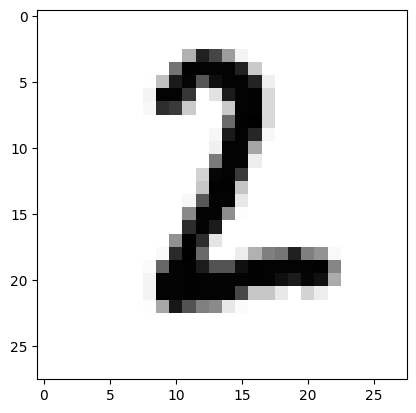

In [40]:
# 테스트 데이터를 사용하여 모델 평가
# gradient 계산 수행 X
with torch.no_grad():
  X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  prediction = linear(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test
  accuracy = correct_prediction.float().mean()
  print("Accuracy:", accuracy.item())

  # MNIST 테스트 데이터에서 무작위로 하나를 뽑아서 예측
  r = random.randint(0, len(mnist_test) - 1)
  X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
  Y_single_data = mnist_test.test_labels[r:r+1].to(device)

  print("Label: ", Y_single_data.item())
  single_prediction = linear(X_single_data)
  print("Predicition: ", torch.argmax(single_prediction, 1).item())

  plt.imshow(mnist_test.test_data[r:r+1].view(28, 28), cmap='Greys', interpolation='nearest')
  plt.show()

- 평가 모드 활성화: with torch.no_grad()
- 테스트 데이터 준비:
  - mnist_test.test_data: 테스트 데이터셋의 이미지 데이터를 포함
  - view(-1, 28 * 28): 28x28 크기의 이미지를 일려로 펼쳐 (1, 784) 형태로 변환
  - mnist_test.test_labels: 해당 데이터셋의 레이블(정답) 포함
- 모델 에측 및 정확도 계산:
  - linear(X_test): 테스트 데이터에 대한 모델의 예측 수행
  - torch.argmax(prediction, 1): 각 이미지에 대해 예측된 클래스 레이블 반환
  - correct_prediction: 위 값이 실제 레이블 Y_test 와 동일한지 판단
- 임의의 테스트 샘플 예측:
  - random.randint(0, len(mnist_test) - 1): 테스트 데이터셋에서 임의의 샘플 선택
- 이미지 시각화:
  - plt.imshow(): 선택된 이미지를 시각적으로 표현
    - cmap="Greys": 이미지를 회색조로 표시
    - interpolation="nearest": 이미지를 확대할 때 보간을 최소화, 원본의 형태 유지